In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn  as sns

In [2]:
df =pd.read_csv('quick_commerce_data_modified_cleaned.csv')

In [3]:
print("Shape:", df.shape)

Shape: (947752, 13)


In [4]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947752 entries, 0 to 947751
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  int64  
 5   Delivery_Time_Min        947752 non-null  int64  
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  int64  
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  int64  
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 94.0+ MB


In [6]:
print(df['Company'].unique())

['Swiggy Instamart' 'Flipkart Minutes' 'Dunzo' 'Jio Mart' 'Blinkit'
 'Amazon Now' 'Big Basket' 'Zepto']


In [7]:
print(df['Company'].value_counts())

Company
Flipkart Minutes    118965
Blinkit             118887
Zepto               118565
Swiggy Instamart    118475
Dunzo               118463
Jio Mart            118267
Amazon Now          118083
Big Basket          118047
Name: count, dtype: int64


In [8]:
zepto = df[df['Company'] == 'Zepto']

In [9]:
print("Zepto orders:", zepto.shape[0])

Zepto orders: 118565


In [10]:
duplicates = zepto.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [11]:
# Check unique rating values
print("Unique ratings:", zepto['Customer_Rating'].unique())
print("\nRating distribution:")
print(zepto['Customer_Rating'].value_counts().sort_index())

Unique ratings: [3 4 2 5 1]

Rating distribution:
Customer_Rating
1     7618
2    29763
3    31367
4    30559
5    19258
Name: count, dtype: int64


In [12]:
# Define bad and good ratings
bad = zepto[zepto['Customer_Rating'] <= 2]
good = zepto[zepto['Customer_Rating'] >= 4]

print("Bad rating orders (1-2 stars):", len(bad))
print("Good rating orders (4-5 stars):", len(good))
print("Bad rating percentage:", round(len(bad)/len(zepto)*100, 2), "%")

Bad rating orders (1-2 stars): 37381
Good rating orders (4-5 stars): 49817
Bad rating percentage: 31.53 %


In [13]:
# Compare delivery time between bad and good ratings
print("Average delivery time:")
print("Bad ratings (1-2 stars):", round(bad['Delivery_Time_Min'].mean(), 2), "mins")
print("Good ratings (4-5 stars):", round(good['Delivery_Time_Min'].mean(), 2), "mins")
print("Difference:", round(bad['Delivery_Time_Min'].mean() - good['Delivery_Time_Min'].mean(), 2), "mins")

Average delivery time:
Bad ratings (1-2 stars): 9.67 mins
Good ratings (4-5 stars): 9.65 mins
Difference: 0.02 mins


In [14]:
# Bad rating percentage by city
city_bad = bad['City'].value_counts()
city_total = zepto['City'].value_counts()
city_bad_pct = round((city_bad / city_total * 100), 2).sort_values(ascending=False)
print("Bad rating % by city:")
print(city_bad_pct)

Bad rating % by city:
City
Hyderabad    45.71
Jaipur       33.72
Kolkata      32.84
Chennai      32.65
Haridwar     32.40
Pune         32.28
Amritsar     32.25
Noida        31.99
Gurgaon      31.67
Delhi        27.35
Mumbai       24.91
Bengluru     20.67
Name: count, dtype: float64


In [15]:
# Bad rating percentage by payment method
payment_bad = bad['Payment_Method'].value_counts()
payment_total = zepto['Payment_Method'].value_counts()
payment_bad_pct = round((payment_bad / payment_total * 100), 2).sort_values(ascending=False)
print("Bad rating % by payment method:")
print(payment_bad_pct)

Bad rating % by payment method:
Payment_Method
Debit Card          31.74
Cash on Delivery    31.66
Wallet              31.56
Credit Card         31.34
UPI                 31.34
Name: count, dtype: float64


In [16]:
# Bad rating percentage by product category
cat_bad = bad['Product_Category'].value_counts()
cat_total = zepto['Product_Category'].value_counts()
cat_bad_pct = round((cat_bad / cat_total * 100), 2).sort_values(ascending=False)
print("Bad rating % by product category:")
print(cat_bad_pct)

Bad rating % by product category:
Product_Category
Household              31.81
Beverages              31.73
Groceries              31.59
Dairy                  31.51
Personal Care          31.38
Snacks                 31.36
Fruits & Vegetables    31.31
Name: count, dtype: float64


In [17]:
# Average delivery partner rating in bad vs good orders
print("Avg delivery partner rating:")
print("Bad orders:", round(bad['Delivery_Partner_Rating'].mean(), 2))
print("Good orders:", round(good['Delivery_Partner_Rating'].mean(), 2))

Avg delivery partner rating:
Bad orders: 3.81
Good orders: 3.8


In [18]:
# Average distance in bad vs good orders
print("Average distance:")
print("Bad orders:", round(bad['Distance_Km'].mean(), 2), "km")
print("Good orders:", round(good['Distance_Km'].mean(), 2), "km")

Average distance:
Bad orders: 7.74 km
Good orders: 7.74 km


C:\Users\mitha\AppData\Local\Temp\ipykernel_13376\113305748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=zepto, x='Customer_Rating', palette='RdYlGn')


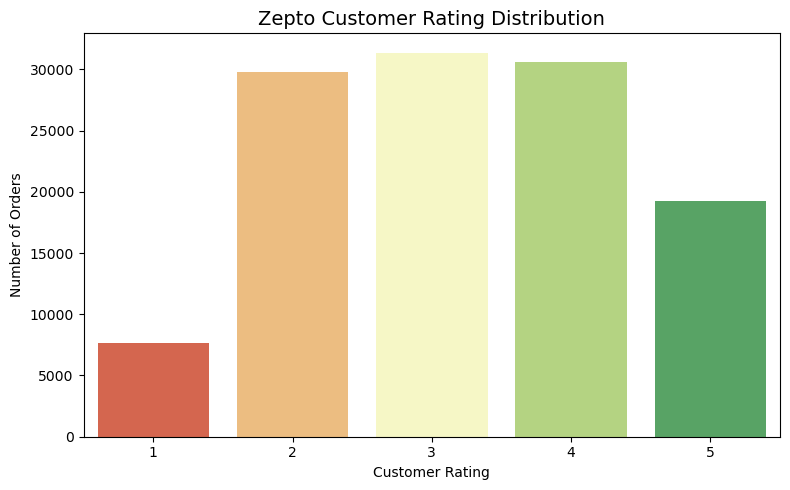

In [19]:
# Chart 1 - Rating Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=zepto, x='Customer_Rating', palette='RdYlGn')
plt.title('Zepto Customer Rating Distribution', fontsize=14)
plt.xlabel('Customer Rating')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

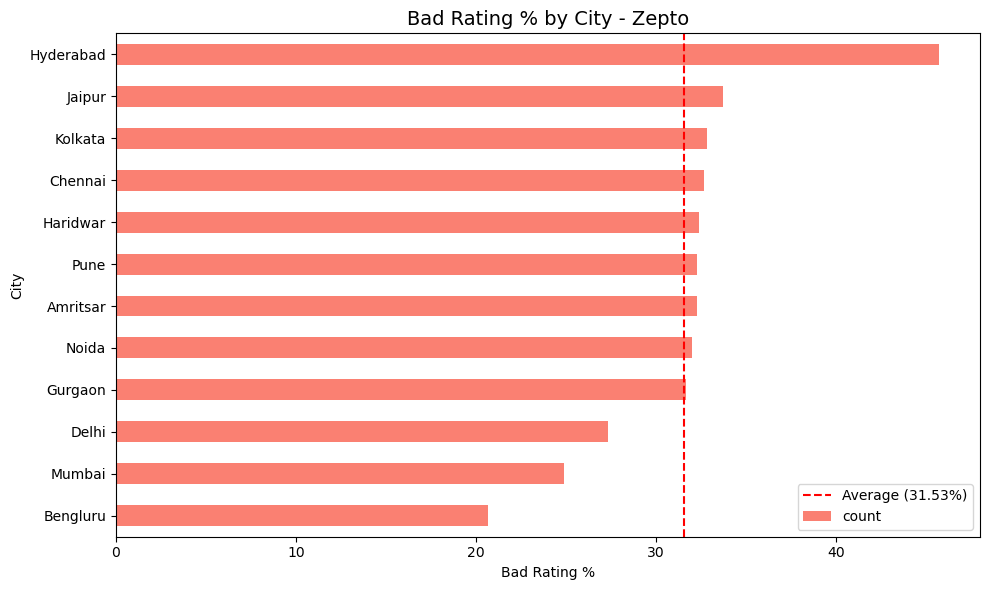

In [20]:
# Chart 2 - Bad Rating % by City
plt.figure(figsize=(10, 6))
city_bad_pct.sort_values().plot(kind='barh', color='salmon')
plt.title('Bad Rating % by City - Zepto', fontsize=14)
plt.xlabel('Bad Rating %')
plt.ylabel('City')
plt.axvline(x=31.53, color='red', linestyle='--', label='Average (31.53%)')
plt.legend()
plt.tight_layout()
plt.show()

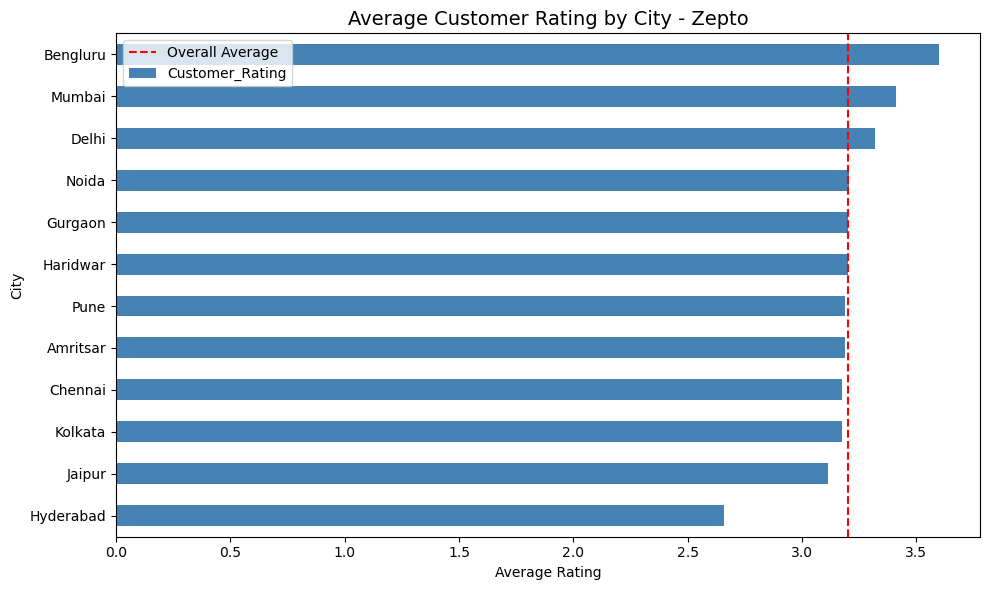

In [21]:
# Chart 3 - Average rating by city
city_avg_rating = zepto.groupby('City')['Customer_Rating'].mean().sort_values()

plt.figure(figsize=(10, 6))
city_avg_rating.plot(kind='barh', color='steelblue')
plt.title('Average Customer Rating by City - Zepto', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('City')
plt.axvline(x=zepto['Customer_Rating'].mean(), color='red', linestyle='--', label='Overall Average')
plt.legend()
plt.tight_layout()
plt.show()

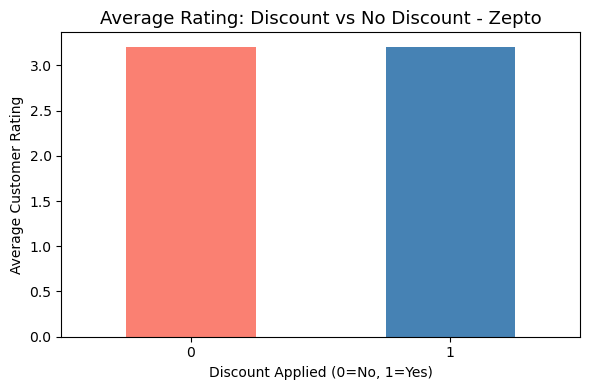

In [22]:
# Chart 4 - Discount Applied vs Rating
discount_rating = zepto.groupby('Discount_Applied')['Customer_Rating'].mean()

plt.figure(figsize=(6, 4))
discount_rating.plot(kind='bar', color=['salmon', 'steelblue'])
plt.title('Average Rating: Discount vs No Discount - Zepto', fontsize=13)
plt.xlabel('Discount Applied (0=No, 1=Yes)')
plt.ylabel('Average Customer Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
    print("""
================================================
ZEPTO CUSTOMER RATING ANALYSIS - KEY FINDINGS
================================================

BUSINESS QUESTION:
What drives poor customer ratings on Zepto?

KEY FINDINGS:
1. 31.53% of Zepto customers give bad ratings (1-2 stars)
2. Delivery time is NOT the cause (difference: 0.02 mins)
3. Payment method is NOT the cause (all around 31%)
4. Product category is NOT the cause (all around 31%)
5. Distance is NOT the cause (both 7.74 km)
6. City IS the major factor:
   - Hyderabad: 45.71% bad rating (CRITICAL)
   - Bengaluru:  20.67% bad rating (BEST)
   - Difference: 25% gap between worst and best city

RECOMMENDATIONS FOR ZEPTO:
1. PRIORITY 1 - Investigate Hyderabad operations urgently
   - Audit Hyderabad delivery partners
   - Check Hyderabad warehouse operations
   - Survey Hyderabad customers specifically

2. PRIORITY 2 - Replicate Bengaluru model
   - Study what Bengaluru does differently
   - Apply same operational model to Hyderabad

3. PRIORITY 3 - Reduce overall 2-star ratings
   - 2-star has 29,763 orders vs 1-star 7,618
   - Converting 2-star to 3-star = biggest impact

EXPECTED IMPACT:
If Hyderabad matches Bengaluru's rating %,
Zepto reduces bad ratings by ~8,000 orders/month
================================================
""")


ZEPTO CUSTOMER RATING ANALYSIS - KEY FINDINGS

BUSINESS QUESTION:
What drives poor customer ratings on Zepto?

KEY FINDINGS:
1. 31.53% of Zepto customers give bad ratings (1-2 stars)
2. Delivery time is NOT the cause (difference: 0.02 mins)
3. Payment method is NOT the cause (all around 31%)
4. Product category is NOT the cause (all around 31%)
5. Distance is NOT the cause (both 7.74 km)
6. City IS the major factor:
   - Hyderabad: 45.71% bad rating (CRITICAL)
   - Bengaluru:  20.67% bad rating (BEST)
   - Difference: 25% gap between worst and best city

RECOMMENDATIONS FOR ZEPTO:
1. PRIORITY 1 - Investigate Hyderabad operations urgently
   - Audit Hyderabad delivery partners
   - Check Hyderabad warehouse operations
   - Survey Hyderabad customers specifically

2. PRIORITY 2 - Replicate Bengaluru model
   - Study what Bengaluru does differently
   - Apply same operational model to Hyderabad

3. PRIORITY 3 - Reduce overall 2-star ratings
   - 2-star has 29,763 orders vs 1-star 7,618
 

In [24]:
# Export 1 - Full Zepto data
zepto.to_csv('zepto_clean.csv', index=False)

# Export 2 - Bad rating % by city
city_bad_pct.reset_index().to_csv('city_bad_rating.csv', index=False)

# Export 3 - Rating distribution
rating_dist = zepto['Customer_Rating'].value_counts().sort_index().reset_index()
rating_dist.columns = ['Rating', 'Count']
rating_dist.to_csv('rating_distribution.csv', index=False)

# Export 4 - Average rating by city
city_avg_rating.reset_index().to_csv('city_avg_rating.csv', index=False)

print("All files exported successfully!")

All files exported successfully!
